In [49]:
import os
import random
from tqdm import tqdm
from samplers import PendulumSampler
from curriculum import Curriculum
from random import randint
import uuid
import ipdb

from quinine import QuinineArgumentParser
import torch
import yaml
from schema import schema
from models import build_model
import math
import random
import numpy as np
import torch
import pickle

from workCon import checking  
from workCon_ebonye import checking as checking_ebonye
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
X0 = [np.pi/3, 3]
# print(0.3 * 180 / math.pi)
print(X0)
n_points = 3
mass = 2
length = 2
T, theta, thetadot, control_values, k_values = checking(X0, n_points, method='rk4', dt=0.01,mass = mass,length = length)
T_ebonye, theta_ebonye, thetadot_ebonye, control_values_ebonye = checking_ebonye(X0, n_points, method='rk4', dt=0.01,mass = mass,length = length)

[1.0471975511965976, 3]


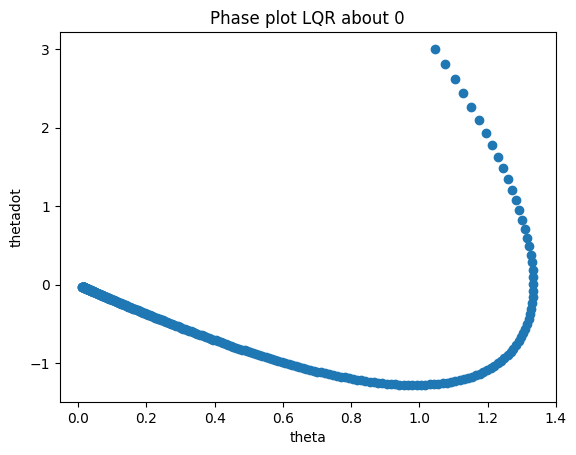

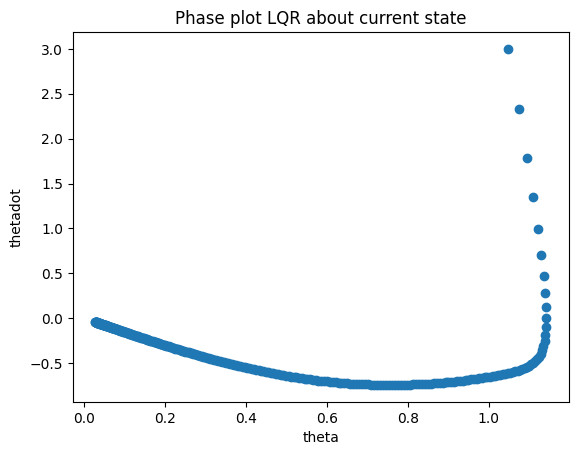

In [ ]:
plt.figure()
plt.scatter(theta,thetadot)
plt.xlabel('theta')
plt.ylabel('thetadot')
plt.title('Phase plot: LQR about 0')
plt.show()

plt.figure()
plt.scatter(theta_ebonye,thetadot_ebonye)
plt.xlabel('theta')
plt.ylabel('thetadot')
plt.title('Phase plot: LQR about current state')
plt.show()

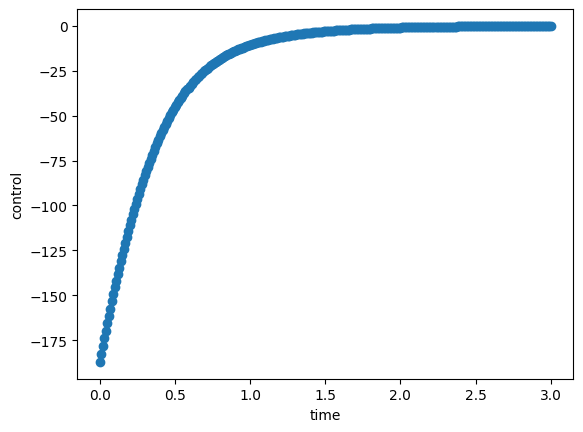

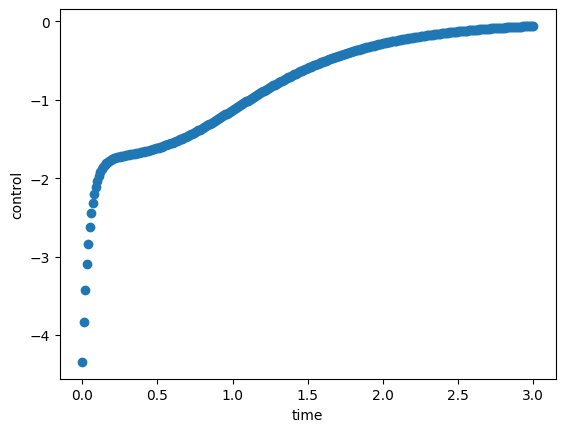

In [ ]:
plt.figure()
plt.scatter(T,control_values)
plt.xlabel('time')
plt.ylabel('control')
plt.title('Control plot: LQR about 0')
plt.show()

plt.figure()
plt.scatter(T_ebonye,control_values_ebonye)
plt.xlabel('time')
plt.ylabel('control')  
plt.title('Control plot: LQR about current state')
plt.show()

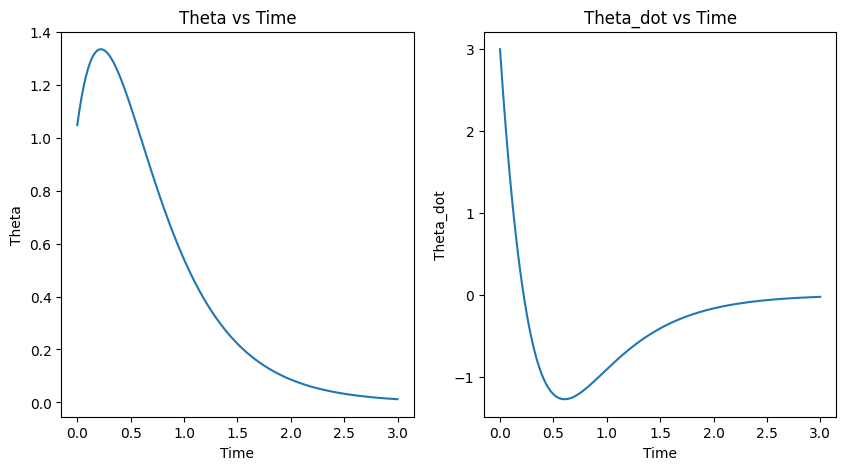

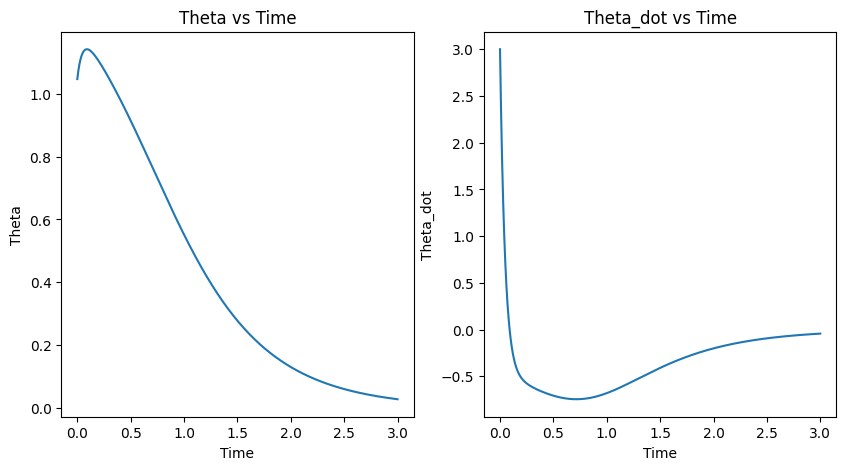

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(T, theta)
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Theta')
ax[0].set_title('Theta vs Time: LQR about 0')
ax[1].plot(T, thetadot)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Theta_dot')
ax[1].set_title('Theta_dot vs Time: LQR about 0')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(T_ebonye, theta_ebonye)
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Theta')
ax[0].set_title('Theta vs Time: LQR about current state')        
ax[1].plot(T_ebonye, thetadot_ebonye)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Theta_dot')
ax[1].set_title('Theta_dot vs Time: LQR about current state')
plt.show()

In [15]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define pendulum dynamics
# g = 9.81  # acceleration due to gravity (m/s^2)
# l = 1.0   # length of the pendulum (m)
# m = 1.0   # mass of the pendulum (kg)
# b = 0.5   # damping coefficient (kg*m/s)

# # Pendulum dynamics function
# def pendulum_dynamics(state, u):
#     theta, theta_dot = state
#     theta_ddot = (g / l) * np.sin(theta) - (b / (m * l**2)) * theta_dot + (1 / (m * l**2)) * u
#     return np.array([theta_dot, theta_ddot])

# # Define cost function
# def cost_function(state, u, target_state):
#     theta, theta_dot = state
#     return 0.5 * (np.dot(state - target_state, state - target_state) + u**2)

# # Linearize the dynamics around the current state and control input
# def linearize_dynamics(state, u):
#     theta, theta_dot = state
#     A = np.array([[0, 1],
#                   [g / l * np.cos(theta), -b / (m * l**2)]])
#     B = np.array([[0], [1 / (m * l**2)]])
#     return A, B

# # Run iLQR
# def ilqr(initial_state, target_state, num_steps, max_iter=50, alpha=1e-2):
#     dt = 0.01
#     state = initial_state
#     u_trajectory = np.zeros(num_steps)  # initial control trajectory

#     # Initial trajectory (zero control input, just for initialization)
#     state_trajectory = np.zeros((num_steps, 2))
#     state_trajectory[0] = state

#     for iter in range(max_iter):
#         # Forward pass: propagate the system using current u_trajectory
#         for t in range(1, num_steps):
#             u = u_trajectory[t-1]
#             state_trajectory[t] = state_trajectory[t-1] + dt * pendulum_dynamics(state_trajectory[t-1], u)

#         # Compute the cost and its gradients (using finite differences)
#         cost = np.sum([cost_function(state_trajectory[t], u_trajectory[t], target_state) for t in range(num_steps)])
#         print(f"Iteration {iter+1}, Cost: {cost}")

#         # Backward pass: calculate LQR updates
#         K = np.zeros((num_steps, 2))  # feedback gains
#         delta_u = np.zeros(num_steps)  # change in control input

#         for t in reversed(range(1, num_steps)):
#             # Linearize dynamics at each step
#             A, B = linearize_dynamics(state_trajectory[t-1], u_trajectory[t-1])

#             # Cost function gradients (using finite differences)
#             Q = np.eye(2)  # state cost
#             R = 1  # control cost

#             P = Q + A.T @ P @ A - (A.T @ P @ B) @ np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A
#             K[t] = np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A

#             # Update control input
#             delta_u[t] = -K[t] @ (state_trajectory[t] - target_state)

#         # Update control trajectory
#         u_trajectory += alpha * delta_u

#         # Check for convergence
#         if np.max(np.abs(delta_u)) < 1e-3:
#             break

#     return state_trajectory, u_trajectory

# # Define initial and target states
# initial_state = np.array([np.pi, 0])  # initial state (downward position)
# target_state = np.array([0, 0])  # target state (upright position)
# num_steps = 100  # number of time steps

# # Run iLQR
# state_trajectory, u_trajectory = ilqr(initial_state, target_state, num_steps)

# # Plot results
# plt.figure(figsize=(12, 6))

# # Plot states (theta, theta_dot)
# plt.subplot(2, 1, 1)
# plt.plot(state_trajectory[:, 0], label='Theta (Angle)')
# plt.plot(state_trajectory[:, 1], label='Theta Dot (Angular Velocity)')
# plt.legend()
# plt.xlabel('Time Step')
# plt.ylabel('State')
# plt.title('Pendulum State Trajectory')

# # Plot control inputs
# plt.subplot(2, 1, 2)
# plt.plot(u_trajectory, label='Control Input (Torque)')
# plt.legend()
# plt.xlabel('Time Step')
# plt.ylabel('Control Input')
# plt.title('Control Input Trajectory')

# plt.tight_layout()
# plt.show()
